<a href="https://colab.research.google.com/github/TEC-A01800371/Reto---Entregas-en-Equipo/blob/main/sesion2_categoricas_numericas_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 2 · Variables categóricas y numéricas
## House Prices — Advanced Regression Techniques

| | |
|---|---|
| **Equipo** |
- Alean Reynoso Rangel A01800849
- Erik Owen Castro Flores A01800371
- Juan Pablo Pérez Gutiérrez A01800483
- Yael Michel García López A01750911
- Alberto Gallegos Hernandez A01752303 |
| **Fecha** | 21 de Agosto de 2026 |
| **Objetivo** | Analizar las variables categóricas y numéricas de House Prices: distribución, cardinalidad, tendencia central, skewness, outliers y correlación con el target. |

---

> Usamos el mismo `train.csv` que descargaron en la sesión 1. Si no lo tienen, revisen las instrucciones de descarga en el notebook de la sesión anterior o del `README.md`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/datos_modulo_3/train (1).csv')
print('Dataset cargado:', df.shape)

Dataset cargado: (1460, 81)


---
## PARTE 1

### 1.1 Categóricas · `value_counts()`

Antes de ver si una variable categórica se relaciona con el target, hay que saber cómo está distribuida ¿está balanceada o hay categorías dominantes?

In [ ]:
df['Neighborhood'].value_counts()

,count
Neighborhood,
NAmes,225
CollgCr,150
OldTown,113
Edwards,100
Somerst,86
Gilbert,79
NridgHt,77
Sawyer,74
NWAmes,73


### 1.2 Relación con el target. `groupby()` + `.mean()`

¿Cambia el precio promedio según el vecindario?

In [ ]:
df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False).round(0)

,SalePrice
Neighborhood,
NoRidge,335295.0
NridgHt,316271.0
StoneBr,310499.0
Timber,242247.0
Veenker,238773.0
Somerst,225380.0
ClearCr,212565.0
Crawfor,210625.0
CollgCr,197966.0


Las diferencias entre vecindarios son de decenas de miles de dólares. `Neighborhood` sí parece tener relación con `SalePrice`. Vale la pena verlo también con un boxplot para ver la distribución completa, no solo el promedio.

### 1.3 Boxplot por categoría

El boxplot muestra la distribución completa del target dentro de cada grupo: mediana, dispersión y outliers, no solo el promedio.

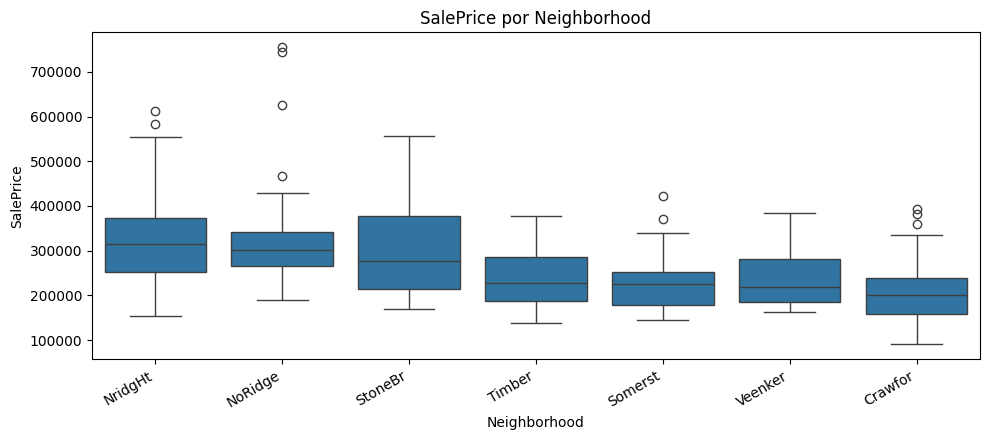

In [ ]:
top_barrios = df.groupby('Neighborhood')['SalePrice'].median().nlargest(7).index

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(data=df[df['Neighborhood'].isin(top_barrios)],
            x='Neighborhood', y='SalePrice', order=top_barrios, ax=ax)
ax.set_title('SalePrice por Neighborhood')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Las medianas entre vecindarios son parecidas (~$265k–$290k) y los IQR se solapan bastante. `Neighborhood` por sí solo no separa limpiamente casas caras de baratas. Todos los vecindarios tienen outliers solo hacia arriba, nunca hacia abajo, primera señal del sesgo positivo de `SalePrice` también dentro de cada grupo, no solo en la distribución global. `OldTown` destaca con 3 outliers marcados (~$620k–$740k), más que el resto, candidata a revisar de cerca.

### 1.4 Tendencia central y dispersión

In [ ]:
print(f"Media:   {df['SalePrice'].mean():,.0f}")
print(f"Mediana: {df['SalePrice'].median():,.0f}")
print(f"Std:     {df['SalePrice'].std():,.0f}")
print(f"Rango:   {df['SalePrice'].min():,.0f} - {df['SalePrice'].max():,.0f}")

Media:   180,921
Mediana: 163,000
Std:     79,443
Rango:   34,900 - 755,000


La media ($180,921) es mayor que la mediana ($163,000). Segunda señal de sesgo positivo.

### 1.5 Skewness

In [ ]:
print(f"SalePrice skew: {df['SalePrice'].skew():.2f}")
print(f"GrLivArea skew: {df['GrLivArea'].skew():.2f}")

SalePrice skew: 1.88
GrLivArea skew: 1.37


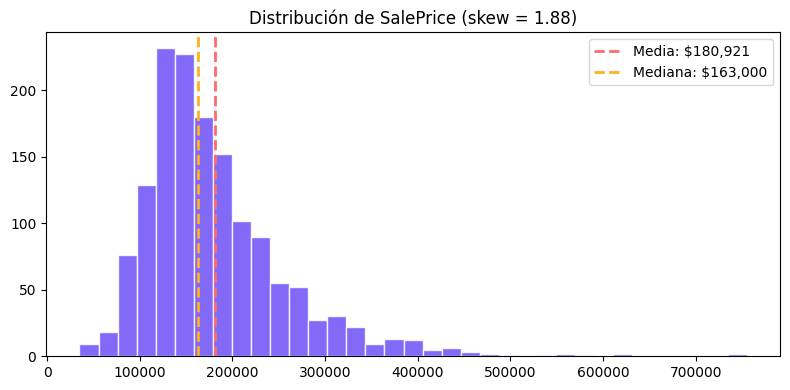

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['SalePrice'], bins=35, color='#6C4FF6', edgecolor='white', alpha=0.85)
ax.axvline(df['SalePrice'].mean(), color='#FF6B6B', linewidth=2, linestyle='--',
           label=f"Media: ${df['SalePrice'].mean():,.0f}")
ax.axvline(df['SalePrice'].median(), color='#FFB020', linewidth=2, linestyle='--',
           label=f"Mediana: ${df['SalePrice'].median():,.0f}")
ax.set_title(f"Distribución de SalePrice (skew = {df['SalePrice'].skew():.2f})")
ax.legend()
plt.tight_layout()
plt.show()

`SalePrice` tiene skew = 1.88 (|γ| > 1). Un sesgo positivo fuerte. `GrLivArea` en cambio tiene skew = 1.37, algo más simétrico.

### 1.6 Outliers · Regla de Tukey (1.5 × IQR)

In [ ]:
Q1 = df['GrLivArea'].quantile(0.25)
Q3 = df['GrLivArea'].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = df[(df['GrLivArea'] < lim_inf) | (df['GrLivArea'] > lim_sup)]

print(f'Q1={Q1:.0f}  Q3={Q3:.0f}  IQR={IQR:.0f}')
print(f'Límites: [{lim_inf:.0f}, {lim_sup:.0f}]')
print(f'Outliers encontrados: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')

Q1=1130  Q3=1777  IQR=647
Límites: [159, 2748]
Outliers encontrados: 31 (2.1%)


> Aplicamos Tukey sobre `GrLivArea` (skew bajo) y no sobre `SalePrice` directamente, con su sesgo de 1.88, la regla generaría muchos falsos positivos en la cola derecha. Eso se corrige transformando primero.

### 1.7 Correlación con el target

In [ ]:
num_cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'YearBuilt', 'LotFrontage']
corr = df[num_cols].corr()

print(corr['SalePrice'].sort_values(ascending=False).round(2))

SalePrice      1.00
OverallQual    0.79
GrLivArea      0.71
YearBuilt      0.52
LotFrontage    0.35
Name: SalePrice, dtype: float64


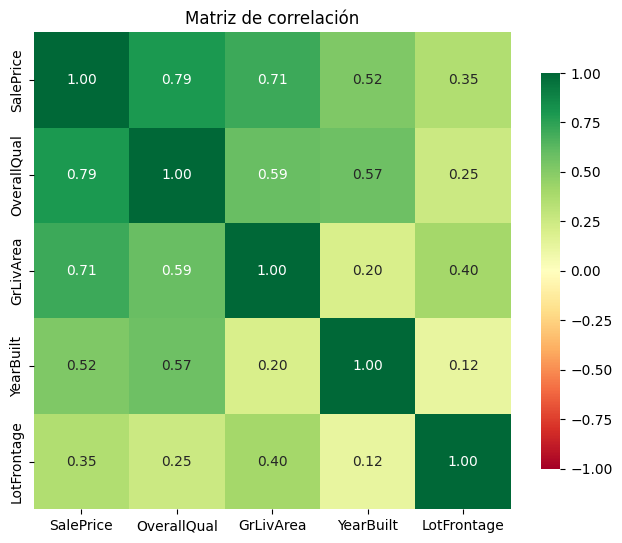

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1,
            ax=ax, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlación')
plt.tight_layout()
plt.show()

`GrLivArea` (0.79) y `OverallQual` (0.71) son las más correlacionadas con `SalePrice` en esta muestra. `LotFrontage` prácticamente no tiene relación lineal (0.35), es candidata a descartar sin mucho análisis adicional según la estrategia de priorización que vimos en la presentación.

---
## PARTE 2

*A partir de aquí trabajan solos (en equipo). Completen las celdas de código y respondan en las celdas de interpretación.*

**Entregable:** este notebook, con todas las celdas ejecutadas y las interpretaciones completadas.

> Documentación oficial de pandas: [pandas.pydata.org/docs](https://pandas.pydata.org/docs/reference/frame.html).

### 2.1 Tabla de contingencia · `pd.crosstab()`

`pd.crosstab()` no se explicó en detalle en la presentación, búsquenla en la documentación de pandas antes de usarla.

Primero, creamos una categoría de precio a partir de `SalePrice` (ya que `crosstab` funciona mejor entre dos variables categóricas):

In [ ]:
# Creamos una categoría binaria a partir de la mediana
mediana = df['SalePrice'].median()
df['CategoriaPrecio'] = np.where(df['SalePrice'] >= mediana, 'Caro', 'Económico')

df[['SalePrice', 'CategoriaPrecio']].head()

,SalePrice,CategoriaPrecio
0,208500,Caro
1,181500,Caro
2,223500,Caro
3,140000,Económico
4,250000,Caro


### Posteriormente se crea una tabla de contingencia entre CentralAir y CategoriaPrecio

In [ ]:
contingency_table = pd.crosstab(df['CentralAir'], df['CategoriaPrecio'])
display(contingency_table)

CategoriaPrecio,Caro,Económico
CentralAir,,
N,7,88
Y,725,640


In [ ]:
# Con normalize='index' obtenemos proporciones por fila en ve z de conteos


In [ ]:
contingency_table_normalized = pd.crosstab(df['CentralAir'], df['CategoriaPrecio'], normalize='index')
display(contingency_table_normalized.round(2))

CategoriaPrecio,Caro,Económico
CentralAir,,
N,0.07,0.93
Y,0.53,0.47


**Interpretación:**

*¿Las casas con aire acondicionado central (`CentralAir = 'Y'`) tienden más a estar en la categoría 'Caro'? ¿Qué proporción de las casas sin aire acondicionado caen en cada categoría?*

Sí, las casas con aire acondicionado central (CentralAir = 'Y') tienden significativamente más a estar en la categoría 'Caro'. Según la tabla de contingencia normalizada, el 53% de las casas con aire acondicionado central son 'Caras', mientras que solo el 7% de las casas sin aire acondicionado (CentralAir = 'N') caen en esa categoría. Esto muestra una fuerte relación entre la presencia de aire acondicionado central y un precio de venta más alto.

Para las casas sin aire acondicionado (CentralAir = 'N'), la proporción es la siguiente: el 93% caen en la categoría 'Económico' y el 7% en la categoría 'Caro'.

### 2.2 Cardinalidad de todas las variables categóricas

Revisen la cardinalidad de **todas** las columnas categóricas del dataset, no solo `Neighborhood`.

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns
cardinality = {}
for col in categorical_cols:
    cardinality[col] = df[col].nunique()

cardinality_df = pd.DataFrame(cardinality.items(), columns=['Variable', 'Cardinalidad']).sort_values(by='Cardinalidad', ascending=False)
display(cardinality_df)

,Variable,Cardinalidad
8,Neighborhood,25
16,Exterior2nd,16
15,Exterior1st,15
9,Condition1,9
41,SaleType,9
14,RoofMatl,8
10,Condition2,8
12,HouseStyle,8
31,Functional,7
13,RoofStyle,6


**Interpretación:**

*¿Alguna columna tiene cardinalidad sospechosamente alta (cercana al número de filas)? ¿Qué columna del dataset es? ¿Qué se debería de hacer con esta?*

Al revisar la cardinalidad de todas las variables categóricas, ninguna de ellas tiene una cardinalidad sospechosamente alta o cercana al número de filas (1460). La variable categórica con mayor cardinalidad es 'Neighborhood' con 25 valores únicos.

### 2.3 Boxplot de dos variables categóricas adicionales

Elijan **dos** variables categóricas del dataset (distintas a `Neighborhood`) y grafiquen su boxplot contra `SalePrice`.

In [ ]:
# Variable categórica 1

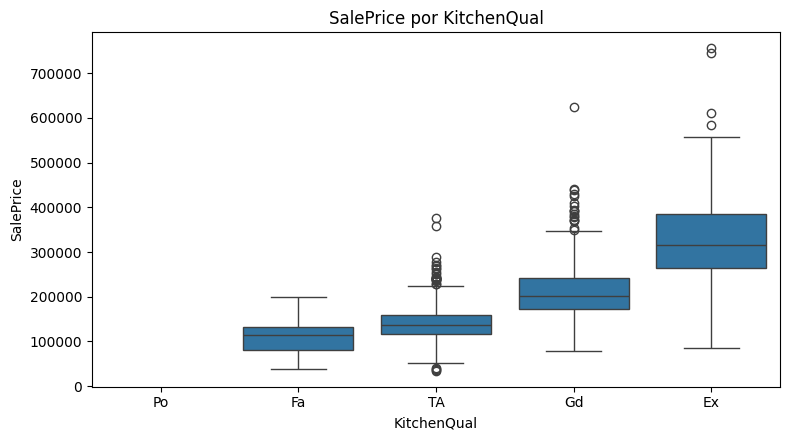

In [ ]:
# Variable categórica 1: KitchenQual
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df, x='KitchenQual', y='SalePrice', ax=ax, order=['Po', 'Fa', 'TA', 'Gd', 'Ex'])
ax.set_title('SalePrice por KitchenQual')
plt.tight_layout()
plt.show()

In [ ]:
# Variable categórica 2

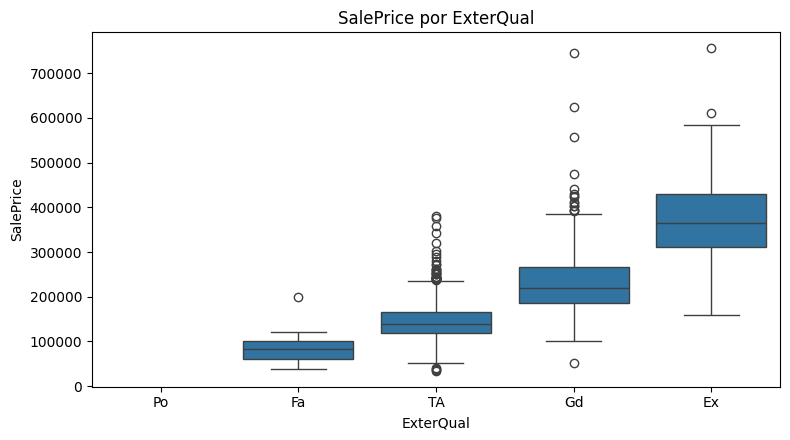

In [ ]:
# Variable categórica 2: ExterQual
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df, x='ExterQual', y='SalePrice', ax=ax, order=['Po', 'Fa', 'TA', 'Gd', 'Ex'])
ax.set_title('SalePrice por ExterQual')
plt.tight_layout()
plt.show()

**Interpretación:**

*Para cada una de las dos variables que eligieron: ¿parece haber una relación clara con SalePrice, o las distribuciones se ven muy parecidas entre categorías?*

KitchenQual: A medida que la calidad de la cocina mejora (de 'Po' a 'Ex'), la mediana y el rango intercuartílico de SalePrice aumentan considerablemente. Esto indica que una mejor calidad de la cocina está asociada con precios de venta más altos. Las categorías 'Gd' y 'Ex' tienen distribuciones de precios notablemente superiores a las de 'Po', 'Fa' y 'TA'.

ExterQual: De manera similar a KitchenQual, una mejor calidad del exterior ('ExterQual') también se correlaciona con precios de venta más altos. Las distribuciones de SalePrice se desplazan hacia arriba a medida que la calidad exterior mejora, mostrando una clara distinción entre las categorías. Las casas con 'Ex' (Excelente) calidad exterior tienen precios significativamente más altos que las de calidad 'Po' (Pobre) o 'Fa' (Mala).

### 2.4 Skewness de todas las variables numéricas

Calculen el skewness de todas las columnas numéricas a la vez (no solo `SalePrice` y `GrLivArea`) y ordénenlas de mayor a menor sesgo.

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
skewness_values = df[numeric_cols].skew().sort_values(ascending=False)
display(skewness_values)

,0
MiscVal,24.476794
PoolArea,14.828374
LotArea,12.207688
3SsnPorch,10.304342
LowQualFinSF,9.011341
KitchenAbvGr,4.488397
BsmtFinSF2,4.255261
ScreenPorch,4.122214
BsmtHalfBath,4.103403
EnclosedPorch,3.089872


**Interpretación:**

*¿Qué variables tienen |skew| > 1? ¿Alguna las sorprendió?*

Las variables numéricas con un valor absoluto de skewness mayor a 1 (|skew| > 1) son muchas y generalmente indican un sesgo considerable (cola larga en una dirección). Las más destacadas, ordenadas de mayor a menor sesgo positivo, son:

MiscVal (24.48)

PoolArea (14.83)

LotArea (12.21)

3SsnPorch (10.30)

LowQualFinSF (9.01)

KitchenAbvGr (4.49)

BsmtFinSF2 (4.26)

ScreenPorch (4.12)

BsmtHalfBath (4.10)

EnclosedPorch (3.09)

MasVnrArea (2.67)

OpenPorchSF (2.36)

LotFrontage (2.16)

SalePrice (1.88)

BsmtFinSF1 (1.69)

WoodDeckSF (1.54)

TotalBsmtSF (1.52)

MSSubClass (1.41)

1stFlrSF (1.38)

GrLivArea (1.37)

### 2.5 Matriz de correlación completa

En la demo solo usamos 5 columnas numéricas. Ahora calculen la matriz de correlación con **todas** las columnas numéricas del dataset.

SalePrice        1.00
OverallQual      0.79
GrLivArea        0.71
GarageCars       0.64
GarageArea       0.62
TotalBsmtSF      0.61
1stFlrSF         0.61
FullBath         0.56
TotRmsAbvGrd     0.53
YearBuilt        0.52
YearRemodAdd     0.51
GarageYrBlt      0.49
MasVnrArea       0.48
Fireplaces       0.47
BsmtFinSF1       0.39
LotFrontage      0.35
WoodDeckSF       0.32
2ndFlrSF         0.32
OpenPorchSF      0.32
HalfBath         0.28
LotArea          0.26
BsmtFullBath     0.23
BsmtUnfSF        0.21
BedroomAbvGr     0.17
ScreenPorch      0.11
PoolArea         0.09
MoSold           0.05
3SsnPorch        0.04
BsmtFinSF2      -0.01
BsmtHalfBath    -0.02
MiscVal         -0.02
Id              -0.02
LowQualFinSF    -0.03
YrSold          -0.03
OverallCond     -0.08
MSSubClass      -0.08
EnclosedPorch   -0.13
KitchenAbvGr    -0.14
Name: SalePrice, dtype: float64


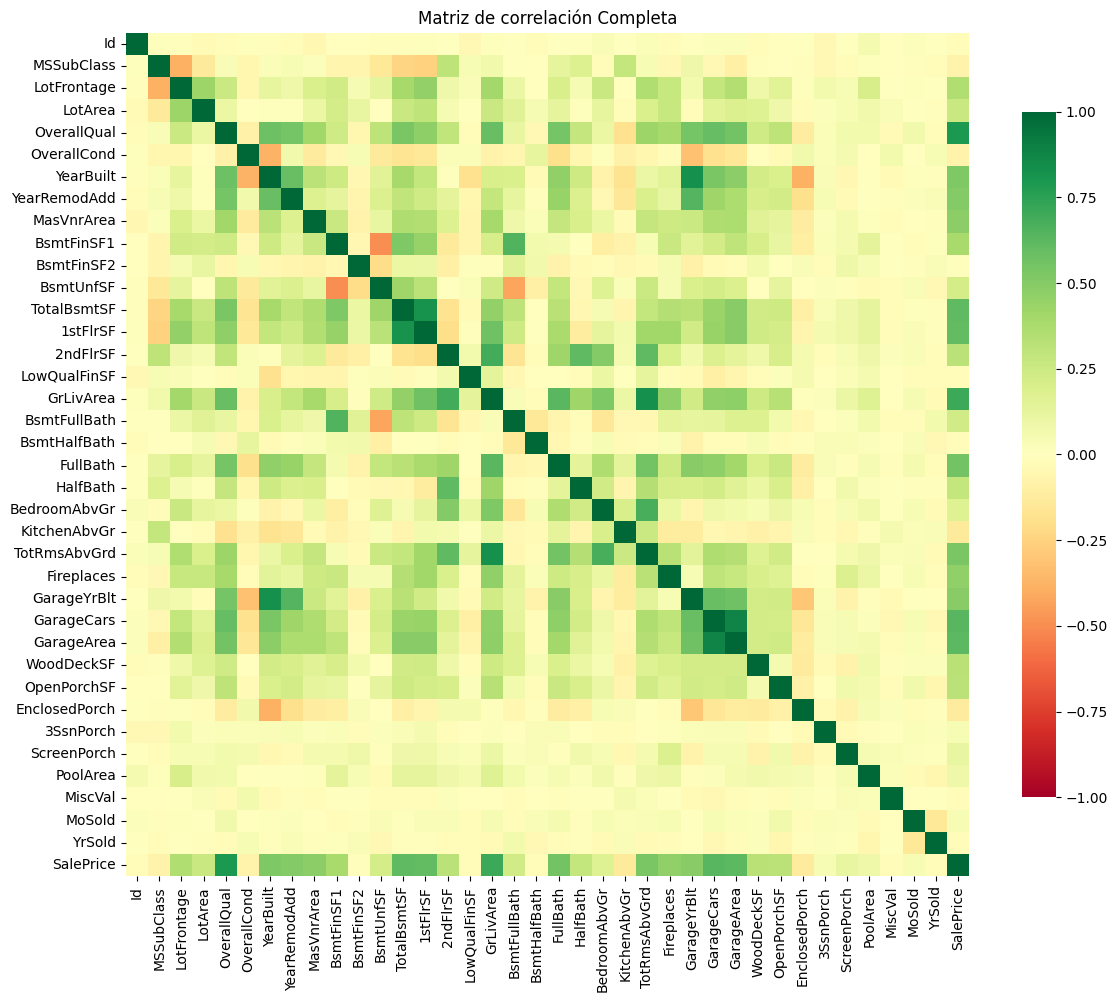

In [ ]:
full_numeric_cols = df.select_dtypes(include=np.number).columns
full_corr = df[full_numeric_cols].corr()

print(full_corr['SalePrice'].sort_values(ascending=False).round(2))

fig, ax = plt.subplots(figsize=(12, 10)) # Adjust figure size for better readability
sns.heatmap(full_corr, annot=False, cmap='RdYlGn', vmin=-1, vmax=1,
            ax=ax, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlación Completa')
plt.tight_layout()
plt.show()

**Interpretación:**

*¿Cuáles son las 3 variables más correlacionadas con SalePrice en el dataset completo? Según la estrategia de priorización de la presentación, ¿en qué variables se enfocarían primero si tuvieran que elegir solo 5 para seguir explorando?*

Las 3 variables más correlacionadas con SalePrice en el dataset completo son:

OverallQual (Calidad general): 0.79

GrLivArea (Área habitable sobre rasante): 0.71

GarageCars (Capacidad de coches en el garaje): 0.64

## Resumen de hallazgos (conclusión del equipo)

| Pregunta | Respuesta del equipo |
|---|---|
| ¿`Neighborhood` parece influir en `SalePrice`? | Sí, las diferencias de precios promedio entre vecindarios son de decenas de miles de dólares, aunque las medianas se solapan. |
| ¿Cuál es la columna categórica con mayor cardinalidad (aparte de un ID)? | `Neighborhood` (25 valores únicos). |
| ¿`SalePrice` tiene sesgo? ¿Positivo o negativo, y qué tan fuerte? | Sí, tiene un sesgo positivo fuerte (skew = 1.88). |
| ¿Qué porcentaje de outliers encontraron en `GrLivArea`? | 2.1% (31 outliers). |
| ¿Cuáles son las 3 variables más correlacionadas con el target? | `OverallQual` (0.79), `GrLivArea` (0.71), `GarageCars` (0.64). |
| ¿Qué variable descartarían de entrada por baja correlación y baja variabilidad? | `LotFrontage` (correlación de 0.35 con `SalePrice`). |